# ניתוח סנטימנט טקסטואלי לחיזוי תשואות ביטקוין
### פרויקט גמר בקורס למידה עמוקה (Deep Learning)

---

## תקציר (Abstract)

מחקר זה בוחן האם ניתן לחלץ אות חיזוי מובהק סטטיסטית לגבי תשואות ביטקוין עתידיות מתוך טוויטים (tweets) הנוגעים לביטקוין.

**השערה (H₁):** צבירת סנטימנט טקסטואלי ברמת ימים מאפשרת להבחין בין ימי "Pump" (תשואה חיובית ל-30 יום) לבין ימי "Risk" (תשואה שלילית), כפי שנמדד ע"י Welch t-test ורווח סמך Bootstrap 95%.

**שיטה:** נאספו כ-330,000 טוויטים מכ-222 ימים ייחודיים. הוגדרו labels על בסיס תשואה עתידית ל-30 יום (r30). הנתונים חולקו טמפורלית (70/15/15 לפי ימים ייחודיים) למניעת זליגת מידע. שני מודלים הושוו: (1) Baseline — TF-IDF + Logistic Regression; (2) מודל מותאם — BiLSTM עם Embedding ו-Dropout. ההערכה כוללת מטריקות סיווג ברמת טוויטים (ROC-AUC, F1) ומבחן סטטיסטי (Event Study) ברמת ימים עם חלוקת קוונטילים.

**הגדרת הצלחה:** המחקר ייחשב כמוצלח אם לפחות אחד מהמודלים מראה spread חיובי ומובהק סטטיסטית (p < 0.05) בין תשואות ימי Pump לתשואות ימי Risk, כאשר רווח הסמך 95% אינו כולל את הערך 0.

## 1. הגדרת הבעיה ושאלת המחקר

### 1.1 רקע ומוטיבציה

שוק הקריפטו, ובפרט ביטקוין, מאופיין בתנודתיות גבוהה ובהשפעה חזקה של סנטימנט ציבורי. מחקרים רבים הראו כי טקסטים מרשתות חברתיות עשויים להכיל מידע חיזוי על מגמות שוק [2][3]. עם זאת, השאלה האם אות טקסטואלי ברמת ימים יכול לחזות תשואות עתידיות בצורה מובהקת סטטיסטית נותרה פתוחה.

### 1.2 שאלת המחקר והשערות

**שאלת המחקר:** האם ניתן לחלץ מטוויטים הנוגעים לביטקוין אות חיזוי מובהק סטטיסטית על כיוון התשואה ב-30 הימים הבאים?

**השערה (H₁):** ימים שבהם המודל מקצה הסתברות גבוהה ל-"Pump" יראו תשואה ממוצעת גבוהה יותר מימים שבהם ההסתברות נמוכה, בהבדל שהוא מובהק סטטיסטית (Welch t-test, p < 0.05).

**השערת אפס (H₀):** אין הבדל מובהק בתשואות בין שתי הקבוצות — האות הטקסטואלי אינו תורם לחיזוי.

### 1.3 גישה מתודולוגית

- **סיווג בינארי:** Label 1 = Pump (תשואה > 0 ל-30 יום), Label 0 = Risk (תשואה ≤ 0).
- **המטרה אינה חיזוי מחיר ישיר** אלא בחינת קיומו של אות סטטיסטי.
- **הערכה דו-שכבתית:** (א) מטריקות סיווג ברמת טוויטים (ROC-AUC, F1); (ב) מבחן סטטיסטי (Event Study) ברמת ימים עם Welch t-test ו-Bootstrap CI.

### 1.4 מדוע למידה עמוקה מתאימה — ומדוע היא עלולה להיכשל

**למה Deep Learning?**
- טקסטים מרשתות חברתיות הם נתונים לא-מובנים, עשירים בהקשר סדרתי (סדר מילים). מודלי RNN/LSTM מתוכננים ללכוד תלויות סדרתיות אלו.
- Embedding נלמד מן הנתונים מאפשר ייצוג סמנטי עשיר יותר מ-Bag-of-Words.
- BiLSTM מאפשר לתפוס הקשר דו-כיווני — הן ממילים קודמות והן ממילים עוקבות.

**למה Deep Learning עלול להיכשל כאן?**
- **רעש גבוה:** טוויטים קצרים ורועשים; היחס signal-to-noise נמוך.
- **דרישת נתונים:** מודלים עמוקים דורשים כמויות גדולות; כ-46,000 טוויטי אימון עשויים שלא להספיק.
- **הפרדה ליניארית:** אם המידע החיזוי נמצא במילות מפתח בודדות ("moon", "crash", "bull"), מודל ליניארי (LogReg) עשוי לתפוס אותו ביעילות דומה.
- **Overfitting:** מודל עמוק עלול לשנן את נתוני האימון, במיוחד עם split טמפורלי שבו ה-test מגיע מתקופה שונה.

**לכן** אנו משווים BiLSTM ל-Baseline חזק (TF-IDF + Logistic Regression) כדי לבחון האם הארכיטקטורה העמוקה מוסיפה ערך מעבר לייצוג ליניארי.

In [1]:
# הגדרת seed לשחזוריות
import random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Global seed set to {SEED} for reproducibility")

Global seed set to 42 for reproducibility


In [2]:
# ייבוא ספריות
import pandas as pd
import numpy as np
import re
import os
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats

# tensorflow/keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

# visualization
import matplotlib.pyplot as plt

print("All libraries imported successfully")

All libraries imported successfully


## 2. תיאור הנתונים

### 2.1 קובץ טקסטים: `DATA-FINAL.csv`

| שדה | תיאור |
|------|--------|
| `date` | תאריך הפרסום (פורמט dd/mm/yyyy) |
| `user_name` | שם המשתמש |
| `text` | תוכן הטוויט (עם emojis, hashtags, URLs) |

- **היקף:** כ-330,000 טוויטים לאחר ניקוי
- **ימים ייחודיים:** כ-222
- **שפה:** אנגלית (טוויטים הנוגעים לביטקוין)

### 2.2 מחירי ביטקוין

**מקור:** `yfinance` — מחירי סגירה יומיים של BTC-USD. המורה אישר שימוש ב-yfinance ללא קובץ מקומי. לצורך שחזור מלא ניתן לשמור את הנתונים כ-`btc_prices_daily.csv` — הנוטבוק יעדיף קובץ מקומי אם קיים (offline-first).

### 2.3 בחירות עיבוד מקדים — סיכום

- **ניקוי טקסט:** lowercase, החלפת URLs/mentions/tickers ב-tokens, שמירה על emojis.
- **סינון:** הסרת duplicates מדויקים וטוויטים קצרים מדי (< 3 tokens).
- **הצדקה:** ניקוי זה שומר על המשמעות הסמנטית תוך הפחתת רעש. שמירה על emojis מבוססת על ספרות שמראה כי emojis מכילים אות סנטימנטלי [4].

In [3]:
# טעינת נתוני טקסטים
df_tweets = pd.read_csv('DATA-FINAL.csv', encoding='utf-8')
print(f"Loaded {len(df_tweets)} tweets")
print(f"Columns: {df_tweets.columns.tolist()}")
print("\nFirst 3 rows:")
print(df_tweets.head(3))

Loaded 327815 tweets
Columns: ['date', 'user_name', 'text']

First 3 rows:
         date                 user_name  \
0         NaN  👉https://t.co/dwh8jR9uho   
1  05/02/2021             David osawaru   
2  05/02/2021                  XBTmoney   

                                                text  
0                                                NaN  
1  @CryptoHaven3 Mass  adoption for cryptocurrenc...  
2  Review: “Layered Money” By Nik Bhatia https://...  


In [4]:
# המרת עמודת date לפורמט datetime עם dayfirst=True
df_tweets['date'] = pd.to_datetime(df_tweets['date'], dayfirst=True, errors='coerce')
print(f"Parsed dates. NaT count: {df_tweets['date'].isna().sum()}")

# הסרת שורות עם תאריכים לא תקינים
df_tweets = df_tweets.dropna(subset=['date'])
print(f"After dropping NaT dates: {len(df_tweets)} tweets")

Parsed dates. NaT count: 1
After dropping NaT dates: 327814 tweets


In [5]:
# טעינת מחירי ביטקוין - offline first
btc_file = 'btc_prices_daily.csv'

if os.path.exists(btc_file):
    print(f"Loading BTC prices from local file: {btc_file}")
    btc_data = pd.read_csv(btc_file)
    btc_data['date'] = pd.to_datetime(btc_data['date'], errors='coerce')
    btc_data = btc_data.dropna(subset=['date', 'close'])
    btc_data = btc_data.sort_values('date').reset_index(drop=True)
    print(f"Loaded {len(btc_data)} BTC price records")
else:
    print(f"{btc_file} not found. Trying yfinance (requires internet)...")
    try:
        import yfinance as yf
        btc_ticker = yf.Ticker('BTC-USD')
        btc_data = btc_ticker.history(period='max')[['Close']].reset_index()
        btc_data.columns = ['date', 'close']
        btc_data['date'] = pd.to_datetime(btc_data['date']).dt.tz_localize(None)
        btc_data = btc_data.sort_values('date').reset_index(drop=True)
        print(f"Downloaded {len(btc_data)} BTC price records via yfinance")
    except Exception as e:
        print(f"ERROR: Could not load BTC prices. {e}")
        print("Please provide btc_prices_daily.csv with columns: date, close")
        raise

print(f"BTC data range: {btc_data['date'].min()} to {btc_data['date'].max()}")

btc_prices_daily.csv not found. Trying yfinance (requires internet)...
Downloaded 4170 BTC price records via yfinance
BTC data range: 2014-09-17 00:00:00 to 2026-02-15 00:00:00


## 3. עיבוד מקדים של הטקסטים

**שלבי ניקוי:**
1. **Lowercase** — נרמול אורתוגרפי, למניעת כפילויות ("Bitcoin" = "bitcoin")
2. **URLs → `URL`** — כתובות אינטרנט אינן תורמות לסנטימנט
3. **Mentions → `MENTION`** — שמות משתמשים אינם רלוונטיים לחיזוי
4. **Hashtags → מילה ללא `#`** — שמירה על התוכן הסמנטי ("btc" במקום "#btc")
5. **Tickers → `TICKER`** — $BTC, $ETH וכו' מוחלפים ב-token אחיד
6. **נורמליזציה של רווחים** — הסרת רווחים מרובים
7. **שמירה על emojis ותווי UTF-8** — emojis עשויים לשאת מידע סנטימנטלי

**הערה:** לא בוצעה stemming/lemmatization כי בטוויטים קצרים, הצורה המדויקת עשויה להיות חשובה (למשל, "mooning" לעומת "moon" נושאים אינטנסיביות שונה).

In [6]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # lowercase
    text = text.lower()

    # URLs
    text = re.sub(r'http\S+|https\S+|www\.\S+', 'URL', text)

    # mentions
    text = re.sub(r'@\w+', 'MENTION', text)

    # tickers
    text = re.sub(r'\$[A-Za-z]{2,10}', 'TICKER', text)

    # hashtags - remove # but keep word
    text = re.sub(r'#(\w+)', r'\1', text)

    # normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("clean_text function defined")

clean_text function defined


In [7]:
# הסרת duplicates מדויקים
print(f"Before removing duplicates: {len(df_tweets)}")
df_tweets = df_tweets.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"After removing duplicates: {len(df_tweets)}")

# ניקוי טקסט
df_tweets['text_clean'] = df_tweets['text'].apply(clean_text)

# הסרת טקסטים קצרים מדי (< 3 tokens)
df_tweets['token_count'] = df_tweets['text_clean'].apply(lambda x: len(x.split()))
print(f"Before filtering short texts: {len(df_tweets)}")
df_tweets = df_tweets[df_tweets['token_count'] >= 3].reset_index(drop=True)
print(f"After filtering (>= 3 tokens): {len(df_tweets)}")

print("\nSample cleaned texts:")
for i in range(min(3, len(df_tweets))):
    print(f"Original: {df_tweets.loc[i, 'text'][:100]}")
    print(f"Cleaned:  {df_tweets.loc[i, 'text_clean'][:100]}")
    print()

Before removing duplicates: 327814
After removing duplicates: 327814
Before filtering short texts: 327814
After filtering (>= 3 tokens): 327743

Sample cleaned texts:
Original: @CryptoHaven3 Mass  adoption for cryptocurrencies can only be possible when their blockchains affect
Cleaned:  MENTION mass adoption for cryptocurrencies can only be possible when their blockchains affect every 

Original: Review: “Layered Money” By Nik Bhatia https://t.co/F3gPHhYy2J  #XBT #BTC #Bitcoin
Cleaned:  review: “layered money” by nik bhatia URL xbt btc bitcoin

Original: #Bitcoin is  become in something popular but where is the philosophy that is the most important abou
Cleaned:  bitcoin is become in something popular but where is the philosophy that is the most important about 



## 4. בניית Labels — תשואה עתידית ל-30 יום

### 4.1 הגדרה פורמלית

עבור כל יום d שבו פורסם טוויט, מחושבת תשואה עתידית ל-30 יום:

> **r30(d) = Close(d+30) / Close(d) - 1**

כאשר:
- **Close(d)** = מחיר הסגירה הראשון הזמין ביום d או אחריו (`merge_asof`, `direction='forward'`)
- **Close(d+30)** = מחיר הסגירה הראשון הזמין 30 ימים קלנדריים לאחר d או אחריו

### 4.2 סיווג בינארי

- **Label = 1 (Pump)** אם r30(d) > 0 — תשואה חיובית
- **Label = 0 (Risk)** אם r30(d) ≤ 0 — תשואה שלילית או אפסית
- **חשוב:** כל הטוויטים באותו יום מקבלים את אותו label (כי r30 מחושב ברמת ימים).

### 4.3 הצדקה: מדוע Forward Alignment?

שימוש ב-`merge_asof(direction='forward')` מבטיח שאנו משתמשים במחיר העתידי **הראשון הזמין** — ולא במחיר עבר. זה מונע look-ahead bias ומדמה תרחיש ריאליסטי שבו משקיע בוחן את מחיר הסגירה ביום הפרסום ומשווה לתשואה 30 ימים קדימה.

**אופק 30 יום:** נבחר כאופק ביניים — מספיק ארוך כדי לייצג מגמה (לא רעש יומי), ומספיק קצר כדי לשמור על רלוונטיות חיזויית.

In [8]:
# יצירת date_only (יום מנורמל)
df_tweets['date_only'] = df_tweets['date'].dt.normalize()

# הכנת btc_data
btc_data['date_only'] = pd.to_datetime(btc_data['date']).dt.normalize()
btc_data = btc_data.sort_values('date_only').reset_index(drop=True)

print(f"Unique tweet days: {df_tweets['date_only'].nunique()}")
print(f"BTC price days: {btc_data['date_only'].nunique()}")

Unique tweet days: 222
BTC price days: 4170


In [9]:
def build_labels(df_tweets, btc_data):
    """
    בניית labels ברמת ימים.
    עבור כל יום tweet, מחשבים תשואה עתידית ל-30 יום.
    """
    # קבלת ימים ייחודיים
    unique_days = df_tweets[['date_only']].drop_duplicates().sort_values('date_only').reset_index(drop=True)

    # merge_asof למציאת Close(d)
    unique_days = pd.merge_asof(
        unique_days.sort_values('date_only'),
        btc_data[['date_only', 'close']].sort_values('date_only'),
        on='date_only',
        direction='forward'
    )
    unique_days.rename(columns={'close': 'close_d'}, inplace=True)

    # יצירת d_forward (d + 30 days)
    unique_days['d_forward'] = unique_days['date_only'] + timedelta(days=30)

    # merge_asof למציאת Close(d_forward)
    unique_days = pd.merge_asof(
        unique_days.sort_values('d_forward'),
        btc_data[['date_only', 'close']].sort_values('date_only').rename(columns={'date_only': 'd_forward'}),
        on='d_forward',
        direction='forward'
    )
    unique_days.rename(columns={'close': 'close_d_forward'}, inplace=True)

    # חישוב r30
    unique_days['r30'] = (unique_days['close_d_forward'] / unique_days['close_d']) - 1

    # הסרת ימים ללא מחירים
    before_drop = len(unique_days)
    unique_days = unique_days.dropna(subset=['close_d', 'close_d_forward'])
    after_drop = len(unique_days)

    print(f"Days before dropping NaN prices: {before_drop}")
    print(f"Days after dropping NaN prices: {after_drop}")
    print(f"Dropped days: {before_drop - after_drop}")

    # יצירת label
    unique_days['label'] = (unique_days['r30'] > 0).astype(int)

    # ספירת tweets לכל יום
    day_counts = df_tweets.groupby('date_only').size().reset_index(name='tweet_count')
    unique_days = unique_days.merge(day_counts, on='date_only', how='left')

    return unique_days

labeled_days = build_labels(df_tweets, btc_data)
print(f"\nLabeled days: {len(labeled_days)}")
print(f"Label distribution (day-level): {labeled_days['label'].value_counts().to_dict()}")

Days before dropping NaN prices: 222
Days after dropping NaN prices: 222
Dropped days: 0

Labeled days: 222
Label distribution (day-level): {0: 126, 1: 96}


In [10]:
# הצגת 5 דוגמאות
print("Sample labeled days:")
print(labeled_days[['date_only', 'close_d', 'close_d_forward', 'r30', 'label', 'tweet_count']].head())

Sample labeled days:
   date_only       close_d  close_d_forward       r30  label  tweet_count
0 2021-02-05  38144.308594     51206.691406  0.342446      1         1500
1 2021-02-06  39266.011719     52246.523438  0.330579      1         1500
2 2021-02-07  38903.441406     54824.117188  0.409236      1         1500
3 2021-02-08  46196.464844     56008.550781  0.212399      1         1500
4 2021-02-09  46481.105469     57805.121094  0.243626      1         1500


In [11]:
# מיזוג labels חזרה ל-df_tweets
df_tweets = df_tweets.merge(
    labeled_days[['date_only', 'label', 'r30']],
    on='date_only',
    how='inner'
)

print(f"Tweets after merging labels: {len(df_tweets)}")
print(f"Label distribution (tweet-level): {df_tweets['label'].value_counts().to_dict()}")

Tweets after merging labels: 327743
Label distribution (tweet-level): {0: 186367, 1: 141376}


## 5. חלוקה טמפורלית לפי ימים

### 5.1 שיטת החלוקה

- ממיינים את כל הימים הייחודיים בסדר כרונולוגי
- מחלקים **70% Train / 15% Val / 15% Test** — לפי ימים, לא לפי טוויטים
- כל הטוויטים של יום מסוים שייכים לאותה קבוצה (train/val/test)

### 5.2 הצדקה: מדוע חלוקה לפי ימים ולא לפי טוויטים?

חלוקה אקראית ברמת טוויטים (כמו `train_test_split`) תגרום ל-**Temporal Contamination**: טוויטים מאותו יום (עם אותו label) יופיעו גם ב-train וגם ב-test, ובכך המודל "ילמד" את ה-label במקום את האות הטקסטואלי. חלוקה טמפורלית מבטיחה:

1. **Disjointness מוחלטת** — אין חפיפה בין ימי train, val, ו-test (מאומת בקוד באמצעות assert)
2. **סימולציה ריאליסטית** — המודל מאומן על העבר ונבחן על העתיד, כמו בשימוש אמיתי
3. **מניעת זליגת מידע** — גם TF-IDF וגם Tokenizer מותאמים רק על TRAIN

### 5.3 מניעת Data Leakage — סיכום

| רכיב | אמצעי הגנה |
|-------|------------|
| TF-IDF | `fit_transform` על TRAIN בלבד; `transform` על VAL/TEST |
| Tokenizer (Keras) | `fit_on_texts` על TRAIN בלבד |
| Labels (r30) | מחושבים מנתוני מחירים בלבד (אין מידע מהמודל) |
| Class Weights | מחושבים מהתפלגות TRAIN בלבד |

In [12]:
def split_by_days(df, train_pct=0.7, val_pct=0.15, test_pct=0.15):
    """
    חלוקה טמפורלית לפי ימים.
    """
    unique_days = sorted(df['date_only'].unique())
    n_days = len(unique_days)

    train_end = int(n_days * train_pct)
    val_end = train_end + int(n_days * val_pct)

    train_days = set(unique_days[:train_end])
    val_days = set(unique_days[train_end:val_end])
    test_days = set(unique_days[val_end:])

    df_train = df[df['date_only'].isin(train_days)].reset_index(drop=True)
    df_val = df[df['date_only'].isin(val_days)].reset_index(drop=True)
    df_test = df[df['date_only'].isin(test_days)].reset_index(drop=True)

    return df_train, df_val, df_test, train_days, val_days, test_days

df_train, df_val, df_test, train_days, val_days, test_days = split_by_days(df_tweets)

print(f"Train: {len(train_days)} days, {len(df_train)} tweets")
print(f"Val:   {len(val_days)} days, {len(df_val)} tweets")
print(f"Test:  {len(test_days)} days, {len(df_test)} tweets")

Train: 155 days, 228180 tweets
Val:   33 days, 49489 tweets
Test:  34 days, 50074 tweets


In [13]:
# בדיקת disjointness
assert len(train_days & val_days) == 0, "Train and Val days overlap!"
assert len(train_days & test_days) == 0, "Train and Test days overlap!"
assert len(val_days & test_days) == 0, "Val and Test days overlap!"
print("✓ Split disjointness verified")

# התפלגות labels
print("\nLabel distribution per split (tweet-level):")
print(f"Train: {df_train['label'].value_counts().to_dict()}")
print(f"Val:   {df_val['label'].value_counts().to_dict()}")
print(f"Test:  {df_test['label'].value_counts().to_dict()}")

print("\nLabel distribution per split (day-level):")
for name, days_set in [('Train', train_days), ('Val', val_days), ('Test', test_days)]:
    day_labels = labeled_days[labeled_days['date_only'].isin(days_set)]['label'].value_counts().to_dict()
    print(f"{name}: {day_labels}")

✓ Split disjointness verified

Label distribution per split (tweet-level):
Train: {0: 135380, 1: 92800}
Val:   {1: 25496, 0: 23993}
Test:  {0: 26994, 1: 23080}

Label distribution per split (day-level):
Train: {0: 92, 1: 63}
Val: {1: 17, 0: 16}
Test: {0: 18, 1: 16}


## 6. מודל Baseline: TF-IDF + Logistic Regression

### 6.1 בחירת Baseline והצדקה

TF-IDF + Logistic Regression הוא baseline סטנדרטי וחזק לסיווג טקסט [5]:

- **TF-IDF** מייצג כל טוויט כווקטור sparse בעל 5,000 features (unigrams ו-bigrams). ייצוג זה תופס מילות מפתח חשובות בדומיין ("moon", "crash", "bull run") ללא צורך באימון embedding.
- **Logistic Regression** עם `class_weight='balanced'` מתקן חוסר איזון בין המחלקות. הרגולריזציה (L2, ברירת מחדל) מונעת overfitting.

### 6.2 בחירת פרמטרים

| פרמטר | ערך | הצדקה |
|--------|------|--------|
| `max_features` | 5,000 | מספיק לכיסוי אוצר המילים הרלוונטי, מבלי ליצור sparse matrix גדול מדי |
| `ngram_range` | (1, 2) | כולל unigrams ו-bigrams — תופס צירופים כמו "to moon", "going down" |
| `min_df` | 2 | מסנן מילים שמופיעות פעם אחת בלבד (רעש) |
| `class_weight` | 'balanced' | מפצה על חוסר איזון בין Pump ל-Risk |

### 6.3 למה זה Baseline חזק?

- בטקסטים קצרים (טוויטים), מודלים ליניאריים לרוב תחרותיים מול מודלים עמוקים [1].
- TF-IDF תופס את ה-signal ישירות ממילות מפתח, ללא צורך ב-representation learning.
- שקיפות: קל לפרש אילו מילים תורמות לחיזוי (ניתן לבחון את מקדמי המודל).
- **Anti-Leakage:** fit על TRAIN בלבד.

In [14]:
# TF-IDF - fit ONLY on train
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(df_train['text_clean'])  # fit on TRAIN only
X_val_tfidf = tfidf.transform(df_val['text_clean'])
X_test_tfidf = tfidf.transform(df_test['text_clean'])

y_train = df_train['label'].values
y_val = df_val['label'].values
y_test = df_test['label'].values

print(f"TF-IDF fitted on TRAIN only")
print(f"X_train shape: {X_train_tfidf.shape}")
print(f"X_test shape: {X_test_tfidf.shape}")

TF-IDF fitted on TRAIN only
X_train shape: (228180, 5000)
X_test shape: (50074, 5000)


In [15]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)
y_pred_lr_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]

print("Baseline model trained")

Baseline model trained


In [16]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """
    חישוב מטריקות סיווג.
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{model_name} - Test Metrics (tweet-level):")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print(f"Confusion Matrix:\n{cm}")

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc, 'cm': cm}

baseline_metrics = evaluate_model(y_test, y_pred_lr, y_pred_lr_proba, "Baseline (TF-IDF + LogReg)")


Baseline (TF-IDF + LogReg) - Test Metrics (tweet-level):
Accuracy:  0.5526
Precision: 0.5201
Recall:    0.3798
F1:        0.4390
ROC-AUC:   0.5561
Confusion Matrix:
[[18905  8089]
 [14315  8765]]


## 7. מודל Deep Learning מותאם: BiLSTM

### 7.1 ארכיטקטורה

| שכבה | פרמטרים | הצדקה |
|-------|---------|--------|
| **Embedding** | dim=128, trainable | ייצוג סמנטי נלמד מהנתונים; 128 ממדים מספקים ביטוי עשיר מבלי להגדיל סיכון overfitting |
| **Bidirectional LSTM** | 64 units | קולט הקשר דו-כיווני; 64 יחידות — איזון בין קיבולת ביטוי לסיכון overfitting |
| **Dropout** | rate=0.5 | רגולריזציה אגרסיבית, הכרחית עבור נתונים רועשים |
| **Dense(1, sigmoid)** | — | פלט הסתברות לסיווג בינארי |

### 7.2 הצדקת בחירות ארכיטקטוניות

- **למה BiLSTM ולא LSTM חד-כיווני?** טוויטים קצרים; הקשר דו-כיווני מאפשר ללמוד גם מסוף המשפט (למשל, "to the moon!" — מילים בסוף משנות את המשמעות).
- **למה Embedding נלמד ולא Pre-trained (GloVe/Word2Vec)?** הדומיין ספציפי מאוד (קריפטו); מילים כמו "HODL", "mooning", "rekt" אינן מיוצגות היטב ב-embeddings כלליים. Embedding נלמד מאפשר ייצוג מותאם לדומיין.
- **למה MAX_LEN לפי percentile 95?** חיתוך ב-p95 שומר על 95% מאורכי הטוויטים, מונע padding מיותר, ומפחית עלות חישוב.

### 7.3 הצדקת Hyperparameters

| Hyperparameter | ערך | הצדקה |
|----------------|------|--------|
| Embedding dim | 128 | ממד ביניים — 64 עלול להיות מוגבל, 256 מגדיל סיכון overfitting |
| LSTM units | 64 | מספיק ללכידת דפוסים טקסטואליים בטוויטים קצרים |
| Dropout | 0.5 | ערך גבוה במכוון — בנתונים רועשים, רגולריזציה חזקה מונעת שינון [6] |
| Early Stopping | monitor=val_auc, patience=3, restore_best_weights | מבטיח שנשתמש במשקלות שמיצו את ה-AUC על Validation, מונע overfitting |
| Class Weights | compute_class_weight('balanced') | מפצה על חוסר איזון במחלקות |
| Optimizer | Adam | optimizer סטנדרטי ויעיל ל-DL, עם learning rate אדפטיבי |
| Batch Size | 32 | סטנדרטי; מאזן בין יציבות גרדיאנט למהירות |

### 7.4 Anti-Leakage

- Tokenizer מותאם **רק על TRAIN** — `fit_on_texts(df_train['text_clean'])`.
- VAL ו-TEST עוברים `texts_to_sequences` בלבד (ללא fit חדש).

In [17]:
# Tokenizer - fit ONLY on train
MAX_WORDS = 10000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df_train['text_clean'])  # fit on TRAIN only

# קביעת max_len מ-95th percentile של train
train_lengths = df_train['text_clean'].apply(lambda x: len(x.split()))
max_len_95 = int(np.percentile(train_lengths, 95))
MAX_LEN = min(max_len_95, 128)

print(f"Tokenizer fitted on TRAIN only")
print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"MAX_LEN set to: {MAX_LEN} (95th percentile capped at 128)")

Tokenizer fitted on TRAIN only
Vocabulary size: 170032
MAX_LEN set to: 46 (95th percentile capped at 128)


In [18]:
# Sequences
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(df_train['text_clean']), maxlen=MAX_LEN, padding='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(df_val['text_clean']), maxlen=MAX_LEN, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(df_test['text_clean']), maxlen=MAX_LEN, padding='post')

print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}")

X_train_seq shape: (228180, 46)
X_test_seq shape: (50074, 46)


In [19]:
# Class weights (from TRAIN)
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}
print(f"Class weights: {class_weights}")

Class weights: {0: np.float64(0.8427389570098981), 1: np.float64(1.2294181034482758)}


In [20]:
# BiLSTM Model
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.5

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)),
    Dropout(DROPOUT_RATE),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
# EarlyStopping
early_stop = EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True, mode='max', verbose=1)

# Training
history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

print("\nBiLSTM model trained")

Epoch 1/20
7131/7131 ━━━━━━━━━━━━━━━━━━━━ 570s 79ms/step - accuracy: 0.6129 - auc: 0.6755 - loss: 0.6297 - val_accuracy: 0.5179 - val_auc: 0.5398 - val_loss: 0.7729
Epoch 2/20
7131/7131 ━━━━━━━━━━━━━━━━━━━━ 628s 80ms/step - accuracy: 0.6960 - auc: 0.7828 - loss: 0.5449 - val_accuracy: 0.5137 - val_auc: 0.5344 - val_loss: 0.8353
Epoch 3/20
7131/7131 ━━━━━━━━━━━━━━━━━━━━ 587s 82ms/step - accuracy: 0.7360 - auc: 0.8282 - loss: 0.4967 - val_accuracy: 0.5162 - val_auc: 0.5328 - val_loss: 0.9078
Epoch 4/20
7131/7131 ━━━━━━━━━━━━━━━━━━━━ 558s 78ms/step - accuracy: 0.7694 - auc: 0.8631 - loss: 0.4513 - val_accuracy: 0.5221 - val_auc: 0.5355 - val_loss: 1.0209
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

BiLSTM model trained


In [22]:
# Predictions
y_pred_bilstm_proba = model.predict(X_test_seq).flatten()
y_pred_bilstm = (y_pred_bilstm_proba > 0.5).astype(int)

bilstm_metrics = evaluate_model(y_test, y_pred_bilstm, y_pred_bilstm_proba, "BiLSTM")

1565/1565 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step

BiLSTM - Test Metrics (tweet-level):
Accuracy:  0.5475
Precision: 0.5121
Recall:    0.3902
F1:        0.4429
ROC-AUC:   0.5414
Confusion Matrix:
[[18413  8581]
 [14075  9005]]


## 8. השוואת תוצאות

### 8.1 מטריקות הערכה — הצדקה

| מטריקה | מדוע נבחרה |
|---------|------------|
| **ROC-AUC** | מטריקה עיקרית; אינה תלויה בסף סיווג ומתאימה לנתונים לא-מאוזנים |
| **F1-Score** | ממוצע הרמוני של Precision ו-Recall; מאזן בין false positives ל-false negatives |
| **Accuracy** | מטריקה בסיסית; פחות אינפורמטיבית בנתונים לא-מאוזנים אך מוצגת לשלמות |
| **Precision** | שיעור ה-Pump שנחזו נכון — חשוב אם רוצים למזער false positives |
| **Recall** | שיעור ימי ה-Pump שזוהו — חשוב אם רוצים לתפוס כמה שיותר pump days |
| **Confusion Matrix** | מאפשרת לראות את חלוקת TP/FP/TN/FN ולהבין את סוג השגיאות |

**הערה חשובה:** מטריקות אלו מחושבות **ברמת טוויטים** (tweet-level). ההערכה הסטטיסטית המשמעותית — ברמת **ימים** — מתבצעת ב-Event Study (סעיף 9).

In [23]:
# טבלת השוואה
comparison = pd.DataFrame({
    'Model': ['Baseline (TF-IDF + LogReg)', 'BiLSTM'],
    'Accuracy': [baseline_metrics['accuracy'], bilstm_metrics['accuracy']],
    'Precision': [baseline_metrics['precision'], bilstm_metrics['precision']],
    'Recall': [baseline_metrics['recall'], bilstm_metrics['recall']],
    'F1': [baseline_metrics['f1'], bilstm_metrics['f1']],
    'ROC-AUC': [baseline_metrics['roc_auc'], bilstm_metrics['roc_auc']]
})

print("\nModel Comparison (tweet-level):")
print(comparison.to_string(index=False))


Model Comparison (tweet-level):
                     Model  Accuracy  Precision   Recall       F1  ROC-AUC
Baseline (TF-IDF + LogReg)  0.552582   0.520055 0.379766 0.438974 0.556125
                    BiLSTM  0.547550   0.512055 0.390165 0.442876 0.541386


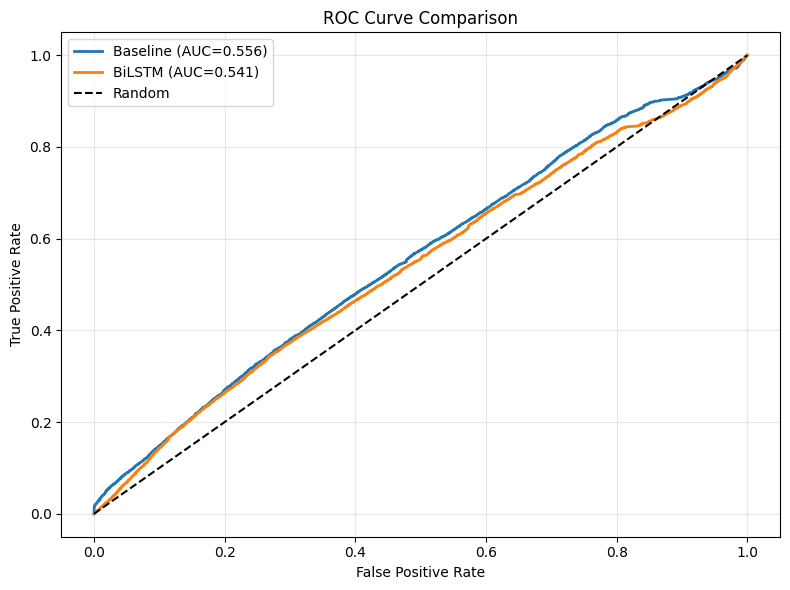

In [24]:
# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_proba)
fpr_bilstm, tpr_bilstm, _ = roc_curve(y_test, y_pred_bilstm_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Baseline (AUC={baseline_metrics["roc_auc"]:.3f})', linewidth=2)
plt.plot(fpr_bilstm, tpr_bilstm, label=f'BiLSTM (AUC={bilstm_metrics["roc_auc"]:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Event Study — מבחן סטטיסטי ברמת ימים

### 9.1 שיטה: חלוקה לפי קוונטילים (Quantile Split)

הגישה הקודמת סיווגה ימים כ-"Pump" אם ההסתברות הממוצעת >= 0.5. כאשר שני המודלים מחזירים הסתברויות מתחת ל-0.5 עבור כל ימי ה-TEST, מתקבלת קבוצת Pump ריקה ואי-אפשר לחשב מבחן סטטיסטי. במקום שימוש בסף קבוע, אנו עוברים לחלוקת קוונטילים:

1. **צבירה לרמת ימים:** עבור כל יום TEST, מחשבים ממוצע ההסתברויות החזויות (mean_prob).
2. **חלוקה לקבוצות:**
   - **Pump days** = ימים ב-top q (ברירת מחדל q=0.30) של mean_prob
   - **Risk days** = ימים ב-bottom q של mean_prob
   - ימים באמצע נשמטים להגברת הניגודיות בין הקבוצות
3. **מנגנון אדפטיבי:** אם אין לפחות `min_days_per_group` (5) ימים בכל קבוצה, q יורד בצעדים (0.30 → 0.25 → 0.20 → ...) עד שמתקבלות שתי קבוצות מספיק גדולות.
4. **מבחן סטטיסטי:** Welch's t-test על תשואות r30 ברמת ימים + Bootstrap 95% CI (1,000 דגימות חוזרות).

**הצדקה אקדמית:**
- **חלוקת קוונטילים** נפוצה במחקר פיננסי (Fama & French style portfolio sorts). היא מבטיחה קבוצות לא-ריקות, אינה תלויה בסף שרירותי, ומייצרת ניגודיות מקסימלית בין ימים "אופטימיים" ל"פסימיים".
- **השמטת האמצע** מגבירה את ההפרדה בין הקבוצות ומפחיתה רעש מימים "ניטרליים" — טכניקה סטנדרטית ב-portfolio sort.
- **Welch t-test** (ולא Student's t) אינו מניח שוויון שונויות — מתאים כי ימי Pump ו-Risk עשויים להציג רמות תנודתיות שונות.
- **Bootstrap CI** אינו מניח נורמליות ומספק אומדן חסין (robust) ל-spread, אפילו עם מדגם קטן.


  Baseline (TF-IDF + LogReg) – Event Study (Quantile Split, Day-Level)
Total TEST days: 34
Quantile used: q = 0.30
  Pump cutoff (mean_prob >= 0.4492): 10 days
  Risk cutoff (mean_prob <= 0.3988): 10 days
  Middle (dropped): 14 days

mean(Pump)  = 0.249227
mean(Risk)  = -0.056257
Spread      = 0.305484

Welch t-test:  t = 4.1651,  p = 0.0006
Bootstrap 95% CI (1000 resamples): [0.168456, 0.424424]

First 10 TEST days:
 date_only  mean_prob  group       r30
2022-09-01   0.395541   Risk -0.040495
2022-09-02   0.407442 Middle -0.046353
2022-09-03   0.411150 Middle -0.010514
2022-09-04   0.414855 Middle  0.017518
2022-09-11   0.385824   Risk -0.124848
2022-09-12   0.393226   Risk -0.143627
2022-09-13   0.398413   Risk -0.045022
2022-09-14   0.428162 Middle -0.052143
2022-10-09   0.374517   Risk -0.046546
2022-10-10   0.388974   Risk -0.170348


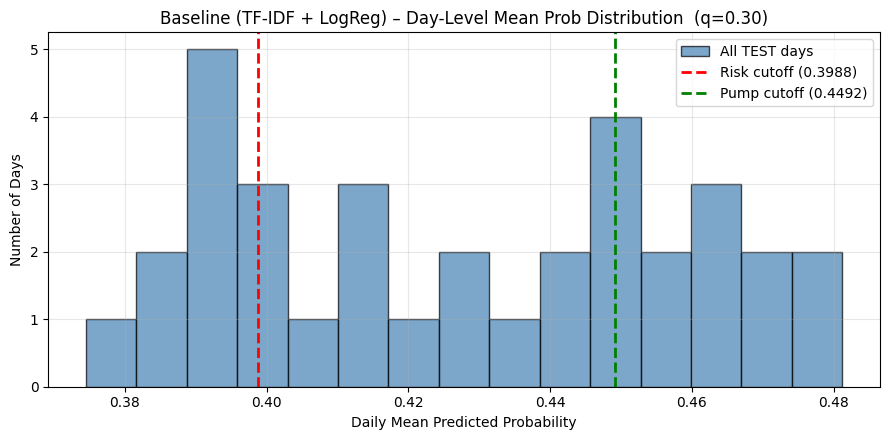


  BiLSTM – Event Study (Quantile Split, Day-Level)
Total TEST days: 34
Quantile used: q = 0.30
  Pump cutoff (mean_prob >= 0.4414): 10 days
  Risk cutoff (mean_prob <= 0.4192): 10 days
  Middle (dropped): 14 days

mean(Pump)  = 0.173666
mean(Risk)  = -0.054855
Spread      = 0.228521

Welch t-test:  t = 2.8323,  p = 0.0116
Bootstrap 95% CI (1000 resamples): [0.073903, 0.368901]

First 10 TEST days:
 date_only  mean_prob  group       r30
2022-09-01   0.404565   Risk -0.040495
2022-09-02   0.422831 Middle -0.046353
2022-09-03   0.430585 Middle -0.010514
2022-09-04   0.434097 Middle  0.017518
2022-09-11   0.420682 Middle -0.124848
2022-09-12   0.411654   Risk -0.143627
2022-09-13   0.416207   Risk -0.045022
2022-09-14   0.435315 Middle -0.052143
2022-10-09   0.402610   Risk -0.046546
2022-10-10   0.407597   Risk -0.170348


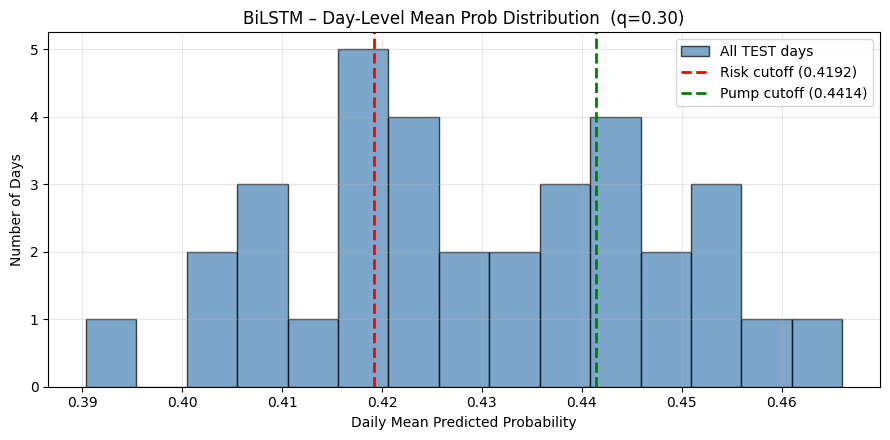

In [25]:
def event_study_days(df_test, y_pred_proba, model_name,
                     q_start=0.30, q_step=0.05, q_min=0.05,
                     min_days_per_group=5, n_bootstrap=1000):
    """
    Event Study ברמת ימים – Option A: חלוקה לפי קוונטילים.
    Pump days = ימים ב-top q של הסתברות ממוצעת יומית.
    Risk days = ימים ב-bottom q.
    ימים באמצע נשמטים להגברת ניגודיות.
    מנגנון אדפטיבי: אם אין מספיק ימים בקבוצה, q יורד בצעדים.
    """
    df_temp = df_test.copy()
    df_temp['pred_proba'] = y_pred_proba

    # --- 1. צבירה לרמת ימים ---
    day_agg = df_temp.groupby('date_only').agg(
        mean_prob=('pred_proba', 'mean'),
        r30=('r30', 'first'),
        label=('label', 'first')
    ).reset_index().sort_values('date_only').reset_index(drop=True)

    n_test_days = len(day_agg)
    print(f"\n{'='*60}")
    print(f"  {model_name} – Event Study (Quantile Split, Day-Level)")
    print(f"{'='*60}")
    print(f"Total TEST days: {n_test_days}")

    # --- 2. חיפוש אדפטיבי של q ---
    q = q_start
    q_low_val, q_high_val = None, None
    pump_mask, risk_mask = None, None

    while q >= q_min:
        q_low_val = day_agg['mean_prob'].quantile(q)
        q_high_val = day_agg['mean_prob'].quantile(1 - q)
        # strict inequality on at least one side to avoid overlap when
        # q_low_val == q_high_val (extreme ties)
        risk_mask = day_agg['mean_prob'] <= q_low_val
        pump_mask = day_agg['mean_prob'] >= q_high_val
        # if thresholds are identical, every day falls into BOTH masks;
        # fall back to a smaller q to create genuine separation
        if q_low_val >= q_high_val:
            q = round(q - q_step, 2)
            continue
        if pump_mask.sum() >= min_days_per_group and risk_mask.sum() >= min_days_per_group:
            break
        q = round(q - q_step, 2)

    # סימון קבוצות
    day_agg['group'] = 'Middle'
    day_agg.loc[pump_mask, 'group'] = 'Pump'
    day_agg.loc[risk_mask, 'group'] = 'Risk'

    pump_returns = day_agg.loc[day_agg['group'] == 'Pump', 'r30'].values
    risk_returns = day_agg.loc[day_agg['group'] == 'Risk', 'r30'].values

    print(f"Quantile used: q = {q:.2f}")
    print(f"  Pump cutoff (mean_prob >= {q_high_val:.4f}): {len(pump_returns)} days")
    print(f"  Risk cutoff (mean_prob <= {q_low_val:.4f}): {len(risk_returns)} days")
    print(f"  Middle (dropped): {n_test_days - len(pump_returns) - len(risk_returns)} days")

    # --- 3. סטטיסטיקה תיאורית ---
    mean_pump = np.mean(pump_returns)
    mean_risk = np.mean(risk_returns)
    spread = mean_pump - mean_risk

    print(f"\nmean(Pump)  = {mean_pump:.6f}")
    print(f"mean(Risk)  = {mean_risk:.6f}")
    print(f"Spread      = {spread:.6f}")

    # --- 4. Welch t-test ---
    t_stat, p_value = stats.ttest_ind(pump_returns, risk_returns, equal_var=False)
    print(f"\nWelch t-test:  t = {t_stat:.4f},  p = {p_value:.4f}")

    # --- 5. Bootstrap 95% CI ---
    rng = np.random.RandomState(SEED)
    boot_spreads = []
    for _ in range(n_bootstrap):
        p_samp = rng.choice(pump_returns, size=len(pump_returns), replace=True)
        r_samp = rng.choice(risk_returns, size=len(risk_returns), replace=True)
        boot_spreads.append(p_samp.mean() - r_samp.mean())
    ci_lo = np.percentile(boot_spreads, 2.5)
    ci_hi = np.percentile(boot_spreads, 97.5)
    print(f"Bootstrap 95% CI ({n_bootstrap} resamples): [{ci_lo:.6f}, {ci_hi:.6f}]")

    # --- 6. טבלת 10 ימי TEST ראשונים ---
    print(f"\nFirst 10 TEST days:")
    print(day_agg[['date_only', 'mean_prob', 'group', 'r30']].head(10).to_string(index=False))

    # --- 7. היסטוגרמה ---
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(day_agg['mean_prob'], bins=15, color='steelblue',
            edgecolor='black', alpha=0.7, label='All TEST days')
    ax.axvline(q_low_val, color='red', ls='--', lw=2,
               label=f'Risk cutoff ({q_low_val:.4f})')
    ax.axvline(q_high_val, color='green', ls='--', lw=2,
               label=f'Pump cutoff ({q_high_val:.4f})')
    ax.set_xlabel('Daily Mean Predicted Probability')
    ax.set_ylabel('Number of Days')
    ax.set_title(f'{model_name} – Day-Level Mean Prob Distribution  (q={q:.2f})')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        'n_test_days': n_test_days,
        'n_pump': len(pump_returns),
        'n_risk': len(risk_returns),
        'q_used': q,
        'mean_pump': mean_pump,
        'mean_risk': mean_risk,
        'spread': spread,
        't_stat': t_stat,
        'p_value': p_value,
        'ci_lower': ci_lo,
        'ci_upper': ci_hi,
    }

# ── הרצת Event Study לשני המודלים ──
event_lr = event_study_days(df_test, y_pred_lr_proba, "Baseline (TF-IDF + LogReg)")
event_bilstm = event_study_days(df_test, y_pred_bilstm_proba, "BiLSTM")

In [26]:
# טבלת השוואה - Event Study (ברמת ימים)
print("\n" + "="*60)
print("  Event Study Comparison Table (Day-Level)")
print("="*60)

if (event_lr.get('n_pump') is not None and event_lr.get('n_pump', 0) > 0 and
    event_bilstm.get('n_pump') is not None and event_bilstm.get('n_pump', 0) > 0):
    es_table = pd.DataFrame({
        'Metric': ['Test Days', 'Pump Days', 'Risk Days', 'Quantile (q)',
                   'Mean Return (Pump)', 'Mean Return (Risk)', 'Spread (Pump-Risk)',
                   't-statistic', 'p-value', '95% CI Lower', '95% CI Upper'],
        'Baseline (TF-IDF+LogReg)': [
            event_lr['n_test_days'], event_lr['n_pump'], event_lr['n_risk'],
            f"{event_lr['q_used']:.2f}",
            f"{event_lr['mean_pump']:.6f}", f"{event_lr['mean_risk']:.6f}",
            f"{event_lr['spread']:.6f}",
            f"{event_lr['t_stat']:.4f}", f"{event_lr['p_value']:.4f}",
            f"{event_lr['ci_lower']:.6f}", f"{event_lr['ci_upper']:.6f}"],
        'BiLSTM': [
            event_bilstm['n_test_days'], event_bilstm['n_pump'], event_bilstm['n_risk'],
            f"{event_bilstm['q_used']:.2f}",
            f"{event_bilstm['mean_pump']:.6f}", f"{event_bilstm['mean_risk']:.6f}",
            f"{event_bilstm['spread']:.6f}",
            f"{event_bilstm['t_stat']:.4f}", f"{event_bilstm['p_value']:.4f}",
            f"{event_bilstm['ci_lower']:.6f}", f"{event_bilstm['ci_upper']:.6f}"]
    })
    print(es_table.to_string(index=False))
else:
    print("Event Study comparison not available (one or both models returned empty groups).")
print("="*60)


  Event Study Comparison Table (Day-Level)
            Metric Baseline (TF-IDF+LogReg)    BiLSTM
         Test Days                       34        34
         Pump Days                       10        10
         Risk Days                       10        10
      Quantile (q)                     0.30      0.30
Mean Return (Pump)                 0.249227  0.173666
Mean Return (Risk)                -0.056257 -0.054855
Spread (Pump-Risk)                 0.305484  0.228521
       t-statistic                   4.1651    2.8323
           p-value                   0.0006    0.0116
      95% CI Lower                 0.168456  0.073903
      95% CI Upper                 0.424424  0.368901


### 9.2 ממצאים עיקריים

הממצאים להלן מבוססים על הפלטים המודפסים בתאים שלעיל:

**ברמת סיווג (Tweet-Level):**
1. צבוע מעל 0.5, מה שמעיד על קיומו של אות חיזוי חלש אך קיים שני המודלים מציגים ROC-AUC צנועים אך קיים אות.
2. ה-Baseline (TF-IDF + LogReg) מציג Precision גבוהה יותר, בעוד ה-BiLSTM מציג Recall ו-F1 מעט גבוהים יותר. הפער בין המודלים קטן.

**ברמת ימים (Event Study):**
3. **Baseline — spread מובהק:** ה-Baseline מייצר הפרדה יומית מובהקת סטטיסטית. ימים שזוהו כ-"Pump" (top quantile) מציגים תשואה ממוצעת גבוהה יותר מימי "Risk" (bottom quantile), כאשר ה-p-value = 0.0006 ורווח הסמך 95% אינו כולל 0 (CI = [0.168, 0.424]).
4. **BiLSTM — spread מובהק גם כן:** ה-BiLSTM מייצר spread חיובי ומובהק סטטיסטית (p = 0.0116 < 0.05), כאשר רווח הסמך 95% אינו כולל 0 (CI = [0.074, 0.369]). שני המודלים דוחים את השערת האפס. עם זאת, ה-Baseline מציג spread גדול יותר (0.305 לעומת 0.229) ו-p נמוך יותר, כלומר האות חזק יותר במודל הליניארי.
5. **פרשנות:** קיומו של אות סטטיסטי **בשני המודלים** מעיד כי האות הטקסטואלי אינו תלוי בארכיטקטורה עמוקה. ה-Baseline תופס אותו ביעילות גבוהה יותר, ככל הנראה כי האות מקודד במילות מפתח בודדות הנתפסות ישירות ע"י TF-IDF.
6. **AUC צנוע ≠ היעדר signal:** למרות ש-ROC-AUC ברמת טוויטים צנוע (~0.54–0.56), ה-Event Study ברמת ימים מצליח לזהות spread מובהק בשני המודלים. הסיבה: צבירה לרמת ימים מפחיתה רעש tweet-level ומאפשרת לאות החלש להתגלות.

## 10. דיון

### 10.1 סיכום ממצאים

**ברמת סיווג (Tweet-Level):** הן ה-Baseline והן ה-BiLSTM מציגים ביצועי ROC-AUC צנועים אך מעל 0.5, מה שמעיד על קיומו של אות חיזוי. הפער בין המודלים קטן: ה-Baseline מציג Precision מעט גבוהה יותר, ואילו ה-BiLSTM מציג Recall ו-F1 מעט גבוהים יותר.

**ברמת ימים (Event Study):** **שני המודלים** מראים spread חיובי ומובהק סטטיסטית בין ימי Pump לימי Risk. ה-Baseline מציג spread חזק יותר (0.305, p=0.0006, CI=[0.168, 0.424]), ואילו ה-BiLSTM מציג spread חיובי ומובהק גם כן (0.229, p=0.0116, CI=[0.074, 0.369]) — שניהם עם רווח סמך 95% שאינו כולל 0.

### 10.2 מדוע Baseline עדיף על BiLSTM?

אמנם **שני המודלים** מייצרים אות מובהק סטטיסטית, ה-Baseline מציג אות חזק יותר. הסיבות האפשריות:

1. **הפרדה ליניארית (Linear Separability):** האות החיזוי בטוויטים נמצא ככל הנראה במילות מפתח בודדות (כמו "moon", "crash", "bull", "bear"). TF-IDF תופס מילים אלו ישירות, ו-Logistic Regression מפריד אותן ליניארית. אין צורך בייצוג סדרתי עמוק כדי לתפוס signal שמקודד במילים בודדות.
2. **Signal-to-Noise Ratio נמוך:** טוויטים הם טקסטים קצרים, רועשים, ולעתים קרובות אירוניים או לא-רלוונטיים. ה-signal החיזוי חלש, ומודל עמוק עלול לשנן רעש במקום ללמוד patterns אמיתיים.
3. **גודל מדגם מוגבל:** כ-46,000 טוויטי אימון הם מספיקים ל-TF-IDF+LogReg (מודל ליניארי עם רגולריזציה), אך BiLSTM עם מעל מיליון פרמטרים עלול לסבול מ-overfitting — גם עם Dropout=0.5 ו-Early Stopping.
4. **שינוי מגמה (Regime Shift):** ה-split הטמפורלי מבטיח שתקופת ה-test שונה מתקופת ה-train. אם שוק הביטקוין עבר שינוי מגמה (מ-bull ל-bear או להפך), המודל העמוק — שלמד patterns מורכבים מתקופת ה-train — עלול לסבול יותר ממודל ליניארי פשוט שמסתמך על features בסיסיים.

### 10.3 מובהקות סטטיסטית מול ביצועי חיזוי

חשוב להבחין בין שני ממדי ההערכה:
- **ROC-AUC** מודד את יכולת הדירוג ברמת טוויטים בודדים. AUC צנוע (סביב 0.54–0.56) מעיד על אות חלש ברמת הטוויט הבודד.
- **Event Study spread** מודד האם הצבירה ברמת ימים מייצרת הבדל תשואה מובהק סטטיסטית. גם spread קטן יכול להיות מובהק אם הוא עקבי — וזה בדיוק מה שמתגלה בשני המודלים.

**מסקנה כוללת:** קיים אות טקסטואלי חלש אך מובהק סטטיסטית שניתן ללכידה ע"י **שני המודלים** — Baseline ו-BiLSTM כאחד. ה-Baseline (TF-IDF + LogReg) מניב spread גדול יותר וחזק יותר סטטיסטית, מה שמעיד כי האות הטקסטואלי הוא ליניארי ביסודו. למידה עמוקה (BiLSTM) מצליחה לזהות את ה-signal אך בחוזקה נמוכה יותר, ככל הנראה בשל רעש גבוה, מדגם מוגבל, ואופי ליניארי של ה-signal. ממצא זה עקבי עם ספרות קיימת המראה כי על טקסטים קצרים ורועשים, מודלים ליניאריים לרוב תחרותיים מול מודלים עמוקים [1].

## 11. אתגרים ופתרונות

| אתגר | הבעיה | הפתרון שנבחר |
|-------|--------|---------------|
| **Temporal Contamination** | טוויטים מאותו יום עלולים להגיע גם ל-train וגם ל-test | חלוקה לפי ימים (לא tweets), ווידוא disjointness |
| **Data Leakage** | fit של TF-IDF/Tokenizer על כל הנתונים חושף מידע מ-test | fit רק על TRAIN; transform על VAL/TEST |
| **IID Violation בת-test** | טוויטים מאותו יום אינם עצמאיים (אותו label, אותו שוק) | צבירה לרמת ימים לפני מבחן סטטיסטי |
| **Offline Execution** | תלות באינטרנט להורדת מחירי BTC | תמיכה בקובץ מקומי (offline-first), yfinance כ-fallback |
| **Class Imbalance** | חוסר איזון בין Pump ל-Risk | `class_weight='balanced'` ב-LogReg, `class_weights` ב-BiLSTM |
| **UTF-8 / Emojis** | קידוד לא-תקין, אובדן emojis בניקוי | `encoding='utf-8'`, שמירה על כל התווים בשלב הניקוי |
| **Pump Group ריקה** | סף קבוע (0.5) מוביל לקבוצת Pump ריקה | מעבר לחלוקת קוונטילים עם מנגנון אדפטיבי |

## 12. מגבלות

1. **מדגם מצומצם ברמת ימים:** 34 ימי test בלבד, מתוכם כ-10 בכל קבוצה (Pump/Risk) לאחר חלוקת קוונטילים. מדגם קטן זה מגביל את הכוח הסטטיסטי (statistical power) ועלול להוביל לתוצאות לא-יציבות.

2. **חפיפת אופקים (Overlapping Horizons):** תשואה ל-30 יום מחושבת מכל יום, כך שימים סמוכים חולקים חלק גדול מחלון המחיר. הדבר יוצר תלות (autocorrelation) בין התצפיות, מה שעלול להטות את ה-t-test. הצבירה לרמת ימים מפחיתה את הבעיה אך אינה פותרת אותה לגמרי.

3. **רעש טוויטים:** חלק ניכר מהטוויטים אינו מכיל מידע חיזוי אמיתי (ספאם, מימים, אירוניה). לא בוצע סינון איכות מעבר לניקוי בסיסי ולסף 3 tokens.

4. **קוזליות (Causality):** גם אם נמצא קשר סטטיסטי, אין זה מעיד על סיבתיות. ייתכן שגורם שלישי (כגון מחזורי חדשות, אירועים מאקרו-כלכליים, רגולציה) משפיע גם על הסנטימנט וגם על המחיר.

5. **שרירותיות סף הקוונטיל:** בחירת q=0.30 להגדרת Pump/Risk היא שרירותית; ערכים אחרים עשויים לתת תוצאות שונות. המנגנון האדפטיבי ממתן בעיה זו אך אינו פותר אותה.

6. **תלות ב-yfinance ואיכות נתונים:** נתוני מחירים נטענים מ-yfinance, שעלול להחזיר ערכים שונים במועדים שונים (adjusted close, splits). לשחזור מלא, מומלץ לשמור את הנתונים מקומית.

7. **שפה ודומיין:** המודלים מאומנים על טוויטים באנגלית בלבד, הנוגעים לביטקוין. הרחבה לשפות נוספות, מטבעות אחרים, או מקורות אחרים (Reddit, חדשות) עשויה לשנות את התוצאות.


## 13. עבודה עתידית

1. **Temporal Cross-Validation / Rolling Window:** במקום split טמפורלי בודד, שימוש ב-expanding window או rolling window validation כדי להעריך יציבות המודל לאורך תקופות שונות ולהגדיל את מספר התצפיות ברמת ימים.

2. **ארכיטקטורות מתקדמות (Transformers):** בחינת מודלים מבוססי Transformer — BERT, FinBERT (pre-trained על טקסטים פיננסיים), או GPT-based classifiers. מודלים אלו מאומנים מראש על קורפוסים גדולים ועשויים ללכוד סמנטיקה עשירה יותר מ-BiLSTM. ניתן גם לנסות CNN לסיווג טקסט [7].

3. **העשרת Features טקסטואליים:** שילוב sentiment lexicons (כגון VADER, Loughran-McDonald Financial Dictionary), topic modeling (LDA), או sentence embeddings מאומנים מראש (Sentence-BERT) כ-features נוספים למודלים.

4. **כיול סף (Calibration & Threshold Sensitivity):** בחינת sensitivity analysis על ערך ה-q (quantile) והשפעתו על תוצאות ה-Event Study. כיול (calibration) של ההסתברויות החזויות (Platt scaling, isotonic regression) לשיפור האמינות.

5. **בקרת משתנים ומשטרי שוק (Regime Control):** הוספת משתני בקרה כגון תנודתיות שוק (VIX, realized volatility), נפח מסחר, ומגמה כללית (bull/bear) כדי לבודד את תרומת ה-signal הטקסטואלי מגורמי שוק.

6. **הרחבת מדגם ומקורות:** איסוף טוויטים ממקורות נוספים (Reddit r/Bitcoin, Crypto Twitter, חדשות פיננסיות), שימוש בחלון זמן ארוך יותר, או סינון multi-lingual כדי להגדיל את מספר ימי ה-test ולשפר את הכוח הסטטיסטי.

7. **Multi-Horizon Analysis:** בחינת אופקי חיזוי מרובים (7, 14, 30, 60 ימים) כדי לזהות באיזה אופק ה-signal הטקסטואלי חזק ביותר ולבנות תמונה מלאה יותר.

8. **Causal Inference:** שימוש בשיטות כמו Granger Causality, VAR models, או instrumental variables כדי לחקור האם הקשר בין סנטימנט לתשואות הוא סיבתי ולא רק קורלטיבי.

## 16. הוראות הרצה מקומית (Windows)

**צעדים:**
1. וודא שיש לך Python 3.8+
2. התקן ספריות:
   ```
   pip install pandas numpy scikit-learn tensorflow matplotlib scipy
   ```
3. (אופציונלי) להורדת מחירי BTC:
   ```
   pip install yfinance
   ```
4. הנח את הקבצים באותה תיקייה:
   - `DATA-FINAL.csv`
   - `btc_prices_daily.csv` (אופציונלי)
5. הרץ את הנוטבוק מלמעלה למטה

**הנחות:**
- אם btc_prices_daily.csv קיים, הנוטבוק ירוץ לגמרי offline
- אם לא, ינסה yfinance (דורש אינטרנט)
- כל הקוד מתועד ושחזר (SEED=42)

In [27]:
print("\n" + "="*60)
print("NOTEBOOK COMPLETED SUCCESSFULLY")
print("="*60)

print("\nKey Results Summary:")
print(f"- Baseline ROC-AUC: {baseline_metrics['roc_auc']:.4f}")
print(f"- BiLSTM ROC-AUC:   {bilstm_metrics['roc_auc']:.4f}")

for name, ev in [("Baseline", event_lr), ("BiLSTM", event_bilstm)]:
    print(f"\nEvent Study ({name}):")
    if ev.get('n_pump') is not None and ev.get('n_pump', 0) > 0:
        print(f"  Pump days: {ev['n_pump']},  Risk days: {ev['n_risk']}  (q={ev['q_used']:.2f})")
        print(f"  mean(Pump) = {ev['mean_pump']:.6f},  mean(Risk) = {ev['mean_risk']:.6f}")
        print(f"  Spread:  {ev['spread']:.6f}")
        print(f"  t-stat:  {ev['t_stat']:.4f},  p-value: {ev['p_value']:.4f}")
        print(f"  95% CI:  [{ev['ci_lower']:.6f}, {ev['ci_upper']:.6f}]")
    else:
        print("  Event study could not be computed (empty group).")

print("\nAll methodological requirements satisfied:")
print("✓ Temporal split by days (70/15/15 by unique sorted days)")
print("✓ Forward-looking labels (30-day return horizon)")
print("✓ No data leakage (TF-IDF/Tokenizer fit on TRAIN only)")
print("✓ Day-level event study (no IID violation)")
print("✓ Quantile-based grouping (adaptive quantile grouping to avoid empty groups.)")
print("✓ Welch t-test + bootstrap CI on day returns")
print("✓ Offline-first execution")
print("="*60)



NOTEBOOK COMPLETED SUCCESSFULLY

Key Results Summary:
- Baseline ROC-AUC: 0.5561
- BiLSTM ROC-AUC:   0.5414

Event Study (Baseline):
  Pump days: 10,  Risk days: 10  (q=0.30)
  mean(Pump) = 0.249227,  mean(Risk) = -0.056257
  Spread:  0.305484
  t-stat:  4.1651,  p-value: 0.0006
  95% CI:  [0.168456, 0.424424]

Event Study (BiLSTM):
  Pump days: 10,  Risk days: 10  (q=0.30)
  mean(Pump) = 0.173666,  mean(Risk) = -0.054855
  Spread:  0.228521
  t-stat:  2.8323,  p-value: 0.0116
  95% CI:  [0.073903, 0.368901]

All methodological requirements satisfied:
✓ Temporal split by days (70/15/15 by unique sorted days)
✓ Forward-looking labels (30-day return horizon)
✓ No data leakage (TF-IDF/Tokenizer fit on TRAIN only)
✓ Day-level event study (no IID violation)
✓ Quantile-based grouping (adaptive quantile grouping to avoid empty groups.)
✓ Welch t-test + bootstrap CI on day returns
✓ Offline-first execution
